In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('customer.csv')
df.head(5)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [7]:
df.dtypes

Names               object
Age                float64
Total_Purchase     float64
Account_Manager      int64
Years              float64
Num_Sites          float64
Onboard_date        object
Location            object
Company             object
Churn                int64
dtype: object

In [8]:
df.drop(['Names','Location','Company', 'Onboard_date'],axis=1,inplace=True)

In [9]:
# sigmoid function
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [10]:
# cost function
def costFunction(X,y,theta):
    m = len(y)
    h = sigmoid(X.dot(theta))
    error = (y*np.log(h) + (1-y)*np.log(1-h))
    cost = -1/m * sum(error)
    grad = 1/m * X.T.dot(h-y)
    return cost,grad

In [11]:
# gradient descent
def gradientDescent(X,y,theta,alpha,it):
    cost_history = np.zeros(it)
    for i in range(it):
        cost,grad = costFunction(X,y,theta)
        theta-=alpha*grad
        cost_history[i]=cost
    return theta,cost_history

In [12]:
# predict function
def predict(X,theta):
    return sigmoid(X.dot(theta))

In [13]:
# accuracy function
def accuracy(y_true,y_pred):
    accuracy = np.sum(y_true==y_pred)/len(y_true)
    return accuracy

In [15]:
# train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('Churn',axis=1),df['Churn'],test_size=0.2,random_state=42)

In [16]:
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
# add intercept
X_train = np.c_[np.ones((X_train.shape[0],1)),X_train]
X_test = np.c_[np.ones((X_test.shape[0],1)),X_test]

In [18]:
# train model
theta,cost_history = gradientDescent(X_train,y_train,np.zeros(X_train.shape[1]),alpha=0.01,it=1000)

Text(0.5, 1.0, 'Cost history')

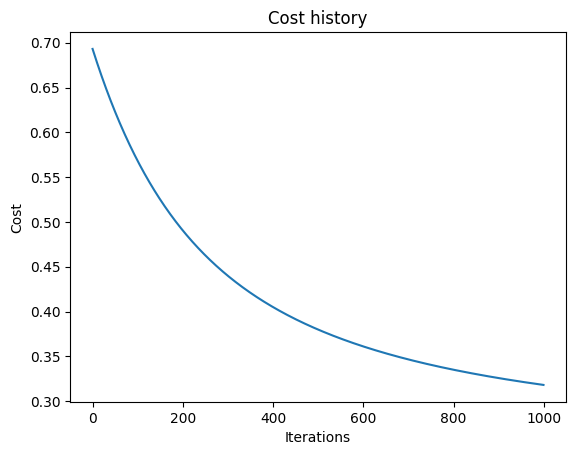

In [19]:
# plot cost history
plt.plot(range(1000),cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost history')

In [24]:
# predict
y_pred = predict(X_test,theta)
y_pred = [1 if i>0.5 else 0 for i in y_pred]
# accuracy
print("Accuracy=",accuracy(y_test, y_pred)*100)

Accuracy= 88.88888888888889


In [28]:
df2 = pd.read_csv('customers_stop.csv')
df2.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company
0,Andrew Mccall,37.0,9935.53,1,7.71,8.0,2011-08-29 18:37:54,38612 Johnny Stravenue Nataliebury WI 15717-8316,King Ltd
1,Michele Wright,23.0,7526.94,1,9.28,15.0,2013-07-22 18:19:54,"21083 Nicole Junction Suite 332, Youngport ME ...",Cannon-Benson
2,Jeremy Chang,65.0,100.00,1,1.00,15.0,2006-12-11 07:48:13,085 Austin Views Lake Julialand WY 63726-4298,Barron-Robertson


In [29]:
df2.drop(['Names','Location','Company', 'Onboard_date'],axis=1,inplace=True)
df2

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
0,37.0,9935.53,1,7.71,8.0
1,23.0,7526.94,1,9.28,15.0
2,65.0,100.00,1,1.00,15.0
3,32.0,6487.50,0,9.40,14.0
4,32.0,13147.71,1,10.00,8.0
5,22.0,8445.26,1,3.46,14.0


In [30]:
# applying prediction
X_new = scaler.transform(df2)
X_new = np.c_[np.ones((X_new.shape[0], 1)), X_new]
y_pred_new = predict(X_new, theta)
y_pred_new = [1 if i > 0.5 else 0 for i in y_pred_new]

# insert prediction into dataframe
df2['Churn'] = y_pred_new
df2

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,37.0,9935.53,1,7.71,8.0,0
1,23.0,7526.94,1,9.28,15.0,1
2,65.0,100.00,1,1.00,15.0,1
3,32.0,6487.50,0,9.40,14.0,1
4,32.0,13147.71,1,10.00,8.0,0
5,22.0,8445.26,1,3.46,14.0,1
